In [7]:
import torch
import torch.nn as nn
import torch.nn.init as init
import torchvision.transforms as transforms
from ultralytics import YOLO
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import sys
import os

YOLO_PATH = '/Users/omrishlezinger/Desktop/Clock-Recognition-And-Manipulation-DL/digital-clock/yolo/yolo.pt' 
CNN_PATH = '/Users/omrishlezinger/Desktop/Clock-Recognition-And-Manipulation-DL/digital-clock/svhn/svhn-cnn.pth'
TEST_IMAGE = [f'/Users/omrishlezinger/Desktop/Clock-Recognition-And-Manipulation-DL/digital-clock/test_images/test_image{i}.png' for i in range(1,7)]

sys.path.append('/Users/omrishlezinger/Desktop/Clock-Recognition-And-Manipulation-DL/') 

from analog_sketch_creator import draw_analog_clock 

device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device: {device}")

Using device: mps


In [2]:
FILTER_SIZES = [5, 5, 5, 5, 5, 5, 5]
NUM_FILTERS = [32, 48, 64, 80, 96, 112, 128]
FC1_SIZE = 1024
FC2_SIZE = 1024
NUM_LABELS = 11 

def init_weights(layer, method='xavier'):
    if isinstance(layer, (nn.Conv2d, nn.Linear)):
        if method == 'he':
            init.kaiming_uniform_(layer.weight, nonlinearity='leaky_relu', a=0.10)
        else:
            init.xavier_uniform_(layer.weight)
        if layer.bias is not None:
            init.constant_(layer.bias, 0.0)

class ConvLayer(nn.Module):
    def __init__(self, in_channels, num_filters, filter_size, pooling=False, initializer='xavier'):
        super(ConvLayer, self).__init__()
        padding = (filter_size - 1) // 2
        self.conv = nn.Conv2d(in_channels, num_filters, kernel_size=filter_size, stride=1, padding=padding)
        self.bn = nn.BatchNorm2d(num_filters)
        self.activation = nn.LeakyReLU(negative_slope=0.10)
        self.pooling = pooling
        if self.pooling:
            self.pool_layer = nn.AvgPool2d(kernel_size=2, stride=2, padding=0)
        init_weights(self.conv, method=initializer)

    def forward(self, x):
        x = self.conv(x)
        x = self.bn(x)
        x = self.activation(x)
        if self.pooling:
            x = self.pool_layer(x)
        return x

class FCLayer(nn.Module):
    def __init__(self, input_dim, output_dim, relu=False, initializer='xavier'):
        super(FCLayer, self).__init__()
        self.fc = nn.Linear(input_dim, output_dim)
        self.use_relu = relu
        if self.use_relu:
            self.activation = nn.LeakyReLU(negative_slope=0.10)
        init_weights(self.fc, method=initializer)

    def forward(self, x):
        x = self.fc(x)
        if self.use_relu:
            x = self.activation(x)
        return x

class SVHNModel(nn.Module):
    def __init__(self, num_channels=1):
        super(SVHNModel, self).__init__()
        
        # Block 1
        self.conv1 = ConvLayer(num_channels, NUM_FILTERS[0], FILTER_SIZES[0], pooling=False)
        self.conv2 = ConvLayer(NUM_FILTERS[0], NUM_FILTERS[1], FILTER_SIZES[1], pooling=True)
        self.drop1 = nn.Dropout(p=0.1) 

        # Block 2
        self.conv3 = ConvLayer(NUM_FILTERS[1], NUM_FILTERS[2], FILTER_SIZES[2], pooling=False)
        self.conv4 = ConvLayer(NUM_FILTERS[2], NUM_FILTERS[3], FILTER_SIZES[3], pooling=True)
        self.drop2 = nn.Dropout(p=0.1)

        # Block 3
        self.conv5 = ConvLayer(NUM_FILTERS[3], NUM_FILTERS[4], FILTER_SIZES[4], pooling=False)
        self.conv6 = ConvLayer(NUM_FILTERS[4], NUM_FILTERS[5], FILTER_SIZES[5], pooling=False)
        self.conv7 = ConvLayer(NUM_FILTERS[5], NUM_FILTERS[6], FILTER_SIZES[6], pooling=True)
        self.drop3 = nn.Dropout(p=0.5)

        self.flat_features = 4 * 4 * NUM_FILTERS[6]
        
        # Fully Connected
        self.fc1 = FCLayer(self.flat_features, FC1_SIZE, relu=True)
        self.drop_fc = nn.Dropout(p=0.5)
        self.fc2 = FCLayer(FC1_SIZE, FC2_SIZE, relu=True)

        # Output Heads (5 digits)
        self.digit1 = FCLayer(FC2_SIZE, NUM_LABELS, relu=False)
        self.digit2 = FCLayer(FC2_SIZE, NUM_LABELS, relu=False)
        self.digit3 = FCLayer(FC2_SIZE, NUM_LABELS, relu=False)
        self.digit4 = FCLayer(FC2_SIZE, NUM_LABELS, relu=False)
        self.digit5 = FCLayer(FC2_SIZE, NUM_LABELS, relu=False)

    def forward(self, x):
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.drop1(x)
        x = self.conv3(x)
        x = self.conv4(x)
        x = self.drop2(x)
        x = self.conv5(x)
        x = self.conv6(x)
        x = self.conv7(x)
        x = self.drop3(x)
        x = x.view(x.size(0), -1)
        x = self.fc1(x)
        x = self.drop_fc(x)
        x = self.fc2(x)
        return self.digit1(x), self.digit2(x), self.digit3(x), self.digit4(x), self.digit5(x)

In [3]:
preprocess = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((32, 32)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,)) # נרמול סטנדרטי ל-SVHN
])

def decode_digits(predictions):
    """
    מקבלת 5 פלטים מהרשת ומחזירה מספר אחד.
    מניחים ש-10 מייצג 'אין ספרה'.
    """
    digit_list = []
    
    # המודל מחזיר Tuple של 5 טנסורים
    for head_output in predictions:
        # מציאת האינדקס עם ההסתברות הכי גבוהה
        pred_idx = torch.argmax(head_output, dim=1).item()
        
        # התעלמות ממחלקה 10 (Null)
        if pred_idx != 10:
            digit_list.append(str(pred_idx))
            
    if not digit_list:
        return 0 # אם לא זוהה כלום
    
    return int("".join(digit_list))

# 3. פונקציית חיתוך עם ריפוד (10%)
def crop_bbox(image, bbox, pad_pct=0.1):
    w, h = image.size
    x1, y1, x2, y2 = bbox
    
    width = x2 - x1
    height = y2 - y1
    
    pad_x = width * pad_pct
    pad_y = height * pad_pct
    
    # הקפדה לא לצאת מגבולות התמונה
    new_x1 = max(0, int(x1 - pad_x))
    new_y1 = max(0, int(y1 - pad_y))
    new_x2 = min(w, int(x2 + pad_x))
    new_y2 = min(h, int(y2 + pad_y))
    
    return image.crop((new_x1, new_y1, new_x2, new_y2))

In [4]:
print("Loading models...")
yolo_model = YOLO(YOLO_PATH)

cnn_model = SVHNModel(num_channels=1).to(device)
# טעינת המשקולות (map_location חשוב אם המודל אומן על חומרה שונה)
# טעינת הקובץ המלא (Checkpoint)
checkpoint = torch.load(CNN_PATH, map_location=device)

# חילוץ המשקולות בלבד מתוך ה-Checkpoint וטעינתן למודל
# אנחנו ניגשים למפתח 'model_state_dict' כי כך זה נשמר בדרך כלל
if 'model_state_dict' in checkpoint:
    cnn_model.load_state_dict(checkpoint['model_state_dict'])
else:
    # מקרה קצה: אם שמרת את זה בשם אחר, או שזו טעות אחרת
    # אבל לפי השגיאה שלך, האופציה הראשונה היא הנכונה.
    cnn_model.load_state_dict(checkpoint)

cnn_model.eval() # מצב Evaluation
print("Models loaded successfully.")

# 2. ביצוע ה-Pipeline
def process_clock_image(img_path):
    original_img = Image.open(img_path).convert('RGB')
    
    # --- שלב א: YOLO ---
    results = yolo_model(original_img, verbose=False)
    boxes = results[0].boxes
    names = results[0].names # המילון {0: 'hours', 1: 'minutes'}
    
    hh_val = None
    mm_val = None
    
    crops = {} # לשמירת התמונות החתוכות להצגה בסוף

    for box in boxes:
        cls_id = int(box.cls[0])
        label = names[cls_id]
        coords = box.xyxy[0].tolist()
        
        # חיתוך עם ריפוד של 10%
        cropped_img = crop_bbox(original_img, coords, pad_pct=0.1)
        crops[label] = cropped_img
        
        # --- שלב ב: הכנה ל-CNN ---
        # המרה ל-Tensor, הוספת Batch Dimension והעברה ל-GPU/MPS
        input_tensor = preprocess(cropped_img).unsqueeze(0).to(device)
        
        # --- שלב ג: חיזוי CNN ---
        with torch.no_grad():
            outputs = cnn_model(input_tensor) # מחזיר 5 ראשים
            
        # --- שלב ד: פענוח ---
        number = decode_digits(outputs)
        
        if label in ['hours', 'hh', '0']: # התאמה לשמות ב-YAML שלך
            hh_val = number
        elif label in ['minutes', 'mm', '1']:
            mm_val = number

    print(f"Detected Time: {hh_val}:{mm_val}")

    if hh_val is None or mm_val is None:
        print("Error: Could not detect both hours and minutes.")
        return

    # --- שלב ה: יצירת הסרטוט ---
    sketch = draw_analog_clock(hh_val, mm_val, return_array=True)

    # --- ויזואליזציה ---
    fig, ax = plt.subplots(1, 4, figsize=(15, 5))

    # תמונה מקורית
    ax[0].imshow(original_img)
    ax[0].set_title("Original")
    ax[0].axis('off')

    # חיתוך שעות
    if 'hours' in crops or 'hh' in crops:
        ax[1].imshow(crops.get('hours', crops.get('hh'))) 
        ax[1].set_title(f"Hours Crop\nPred: {hh_val}")
    ax[1].axis('off')

    # חיתוך דקות
    if 'minutes' in crops or 'mm' in crops:
        ax[2].imshow(crops.get('minutes', crops.get('mm')))
        ax[2].set_title(f"Minutes Crop\nPred: {mm_val}")
    ax[2].axis('off')

    # סרטוט סופי
    ax[3].imshow(sketch)  # No need for cmap, it's already RGB
    ax[3].set_title("Generated Sketch")
    ax[3].axis('off')

    plt.show()

Loading models...
Models loaded successfully.


Detected Time: 18:30


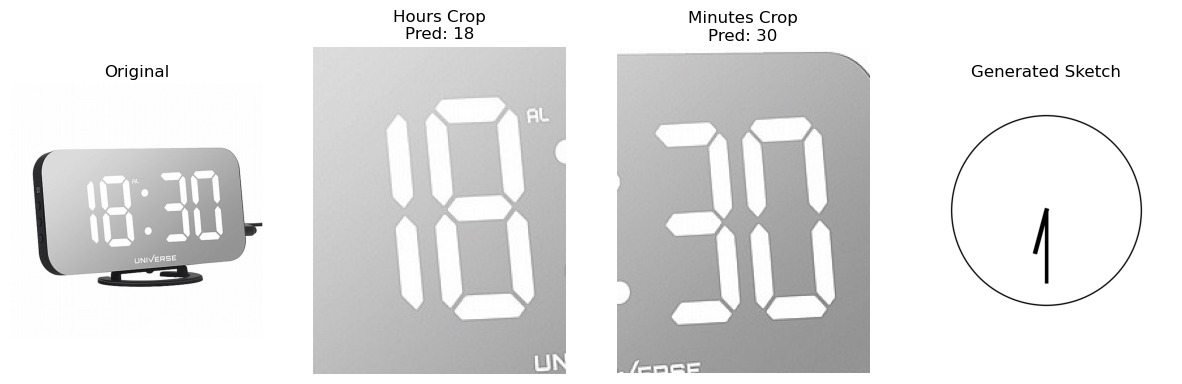

Detected Time: 10:23


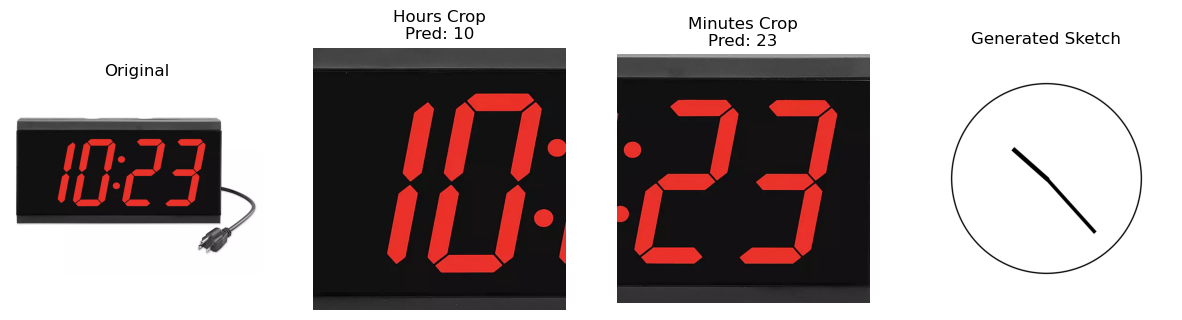

Detected Time: 12:15


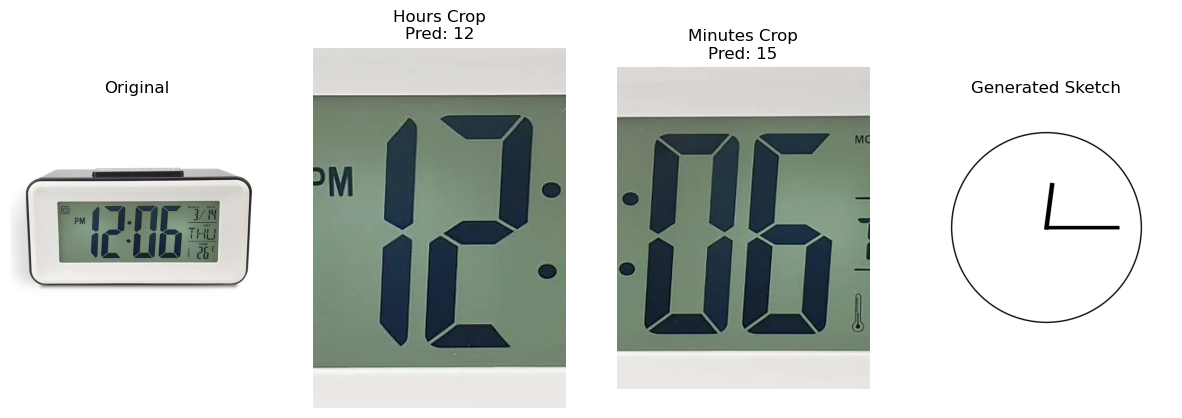

Detected Time: 7:30


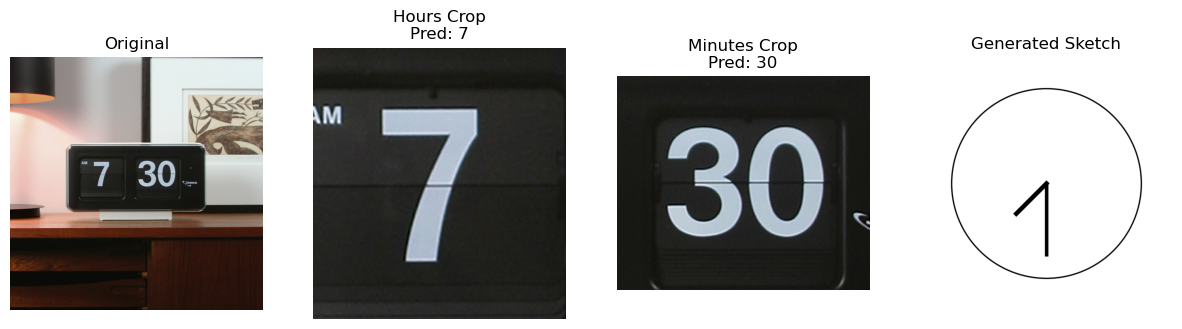

Detected Time: 12:15


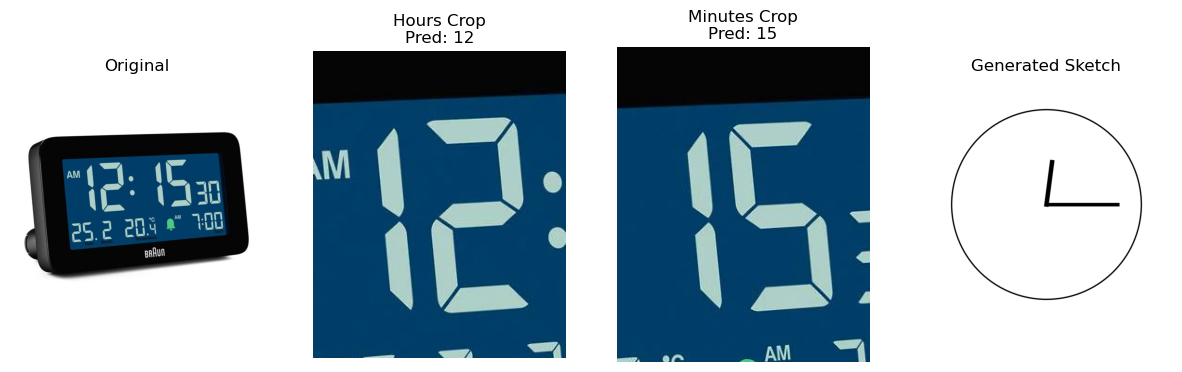

Detected Time: 11:10


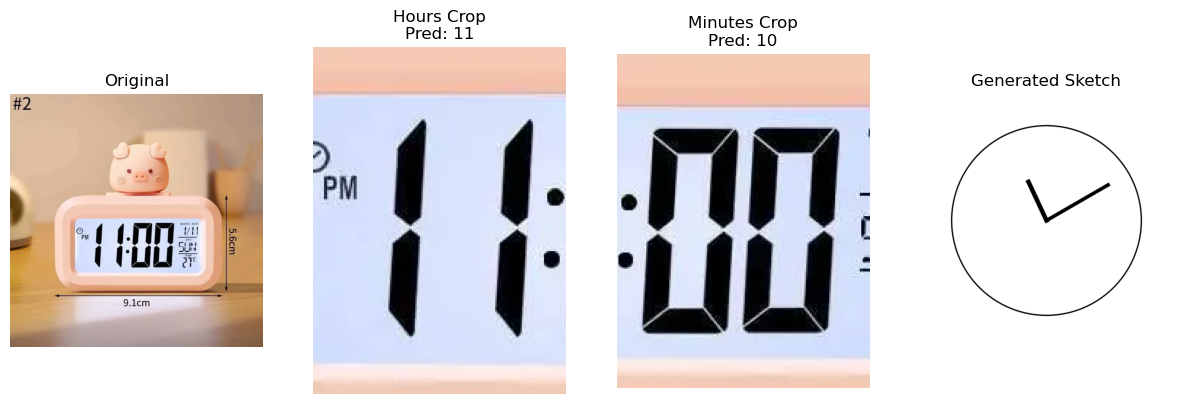

In [11]:
import time
for test in TEST_IMAGE:
    time.sleep(1)
    process_clock_image(test)